# AdaptiveBandit — Customer Support RL Agent
## Contextual Bandits for Real-Time Decision Support in Customer Service

**Objective:** Maximize expected monthly profit per user subject to minimum satisfaction constraints.

This notebook implements the full pipeline from the AML proposal:
1. **Data Pipeline** — Load Twitter CS + OpenAssistant data, build unified dataset
2. **Economic Thresholds** — Derive tier-specific escalation thresholds
3. **Phase I: Contextual Bandits** — LinUCB & Thompson Sampling baselines
4. **Phase II: Full RL (DQN)** — Multi-turn dialogue MDP for Business+/Enterprise
5. **Business-Aligned Evaluation** — Cost saved, CSAT, tier-stratified metrics
6. **Sensitivity Analysis** — CSA cost, churn elasticity, inference cost
7. **Gemini LLM-as-Judge** — Optional enrichment with Gemini API

### Tier Economics (Slack reference pricing, INR)
| Tier | Profit | Escalation Cost | Churn Risk | Driver |
|------|--------|----------------|------------|--------|
| Free | -₹20 | ₹0 | 15% | Network effect |
| Pro | ₹168 | ₹15 | 8% | Volume cash cow |
| Business+ | ₹357 | ₹50 | 3% | Retention |
| Enterprise | ₹600 | ₹100 | 2% | Retention critical |

In [21]:
# ─── Setup & Imports ───
%load_ext autoreload
%autoreload 2

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Add project to path
PROJECT_DIR = r'B:\College\RL\AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service\CustomerSupportBandit'
sys.path.insert(0, PROJECT_DIR)

# Core imports
from config import TIER_CONFIG, TIER_NAMES, TIER_TO_IDX, DATA_PATHS
from data.feature_engineer import FEATURE_DIM, get_feature_names, build_feature_vector
from data.pipeline import build_unified_dataset, generate_synthetic_conversations
from environment.customer_env import CustomerSupportEnv
from agents.rule_based import RuleBasedAgent
from agents.linucb import LinUCBAgent
from agents.thompson_sampling import ThompsonSamplingAgent
from agents.dqn_agent import DQNAgent
from rewards.economic_reward import (
    get_all_thresholds, compute_escalation_threshold,
    compute_economic_reward, compute_monthly_profit, compute_priority_score,
)
from rewards.reward_model import RewardModel
from train import train_bandit, train_dqn, run_experiment, evaluate_on_tiers
from evaluation.metrics import (
    compute_business_metrics, compute_tier_stratified_metrics,
    compute_pareto_metrics, generate_comparison_table,
)
from evaluation.sensitivity import run_full_sensitivity, evaluate_go_no_go
from evaluation.visualize import (
    plot_training_curves, plot_agent_comparison,
    plot_tier_performance, plot_pareto_frontier,
    plot_sensitivity_curves, plot_escalation_thresholds,
    COLORS, TIER_COLORS,
)

SEED = 42
np.random.seed(SEED)
print(f"Feature dimension: {FEATURE_DIM}")
print(f"Feature names: {get_feature_names()}")
print("Setup complete ✓")


Feature dimension: 23
Feature names: ['sentiment_current', 'sentiment_mean', 'sentiment_trend', 'sentiment_volatility', 'sentiment_min', 'avg_word_count', 'max_word_count', 'total_word_count', 'avg_sentence_length', 'technical_term_density', 'has_error_code', 'has_url', 'escalation_phrase_count', 'has_escalation_phrase', 'frustration_score', 'tier_idx', 'tier_profit', 'tier_escalation_cost', 'tier_churn_prob', 'tier_clv', 'tier_csat_floor', 'turn_normalized', 'turn_count']
Setup complete ✓


## 1. Data Pipeline

Build a unified dataset by combining:
- **Twitter CS** (~2.8M tweets → conversation threads with escalation labels)
- **OpenAssistant** (~161K messages → conversation trees with quality ratings)
- **Synthetic** (fallback/supplement with controlled distributions)

Set `USE_REAL_DATA = True` to load the real Twitter + OpenAssistant datasets (requires the data files). Otherwise uses high-quality synthetic conversations.

In [22]:
# ─── Configuration ───
USE_REAL_DATA = False     # Set True to load actual Twitter + OpenAssistant files
TWITTER_SAMPLE = 3000     # Number of Twitter threads to use
OA_SAMPLE = 2000          # Number of OpenAssistant conversation trees
SYNTHETIC_N = 3000        # Number of synthetic conversations
N_EPISODES = 3000         # Training episodes per agent

# Build dataset
train_convs, eval_convs = build_unified_dataset(
    use_twitter=USE_REAL_DATA,
    use_openassistant=USE_REAL_DATA,
    use_synthetic=True,
    twitter_n=TWITTER_SAMPLE,
    oa_n=OA_SAMPLE,
    synthetic_n=SYNTHETIC_N,
    seed=SEED,
)

print(f"\nTrain conversations: {len(train_convs):,}")
print(f"Eval conversations:  {len(eval_convs):,}")

Generated 3,000 synthetic conversations
  Escalation rate: 34.8%
  Avg turns: 5.0
  Tier distribution:
    Free: 60.6%
    Pro: 24.6%
    Business+: 11.4%
    Enterprise: 3.4%

Unified Dataset Summary:
  Total: 3,000 conversations
  Train: 2,400 | Eval: 600
  synthetic: 3,000 (100.0%)

Train conversations: 2,400
Eval conversations:  600


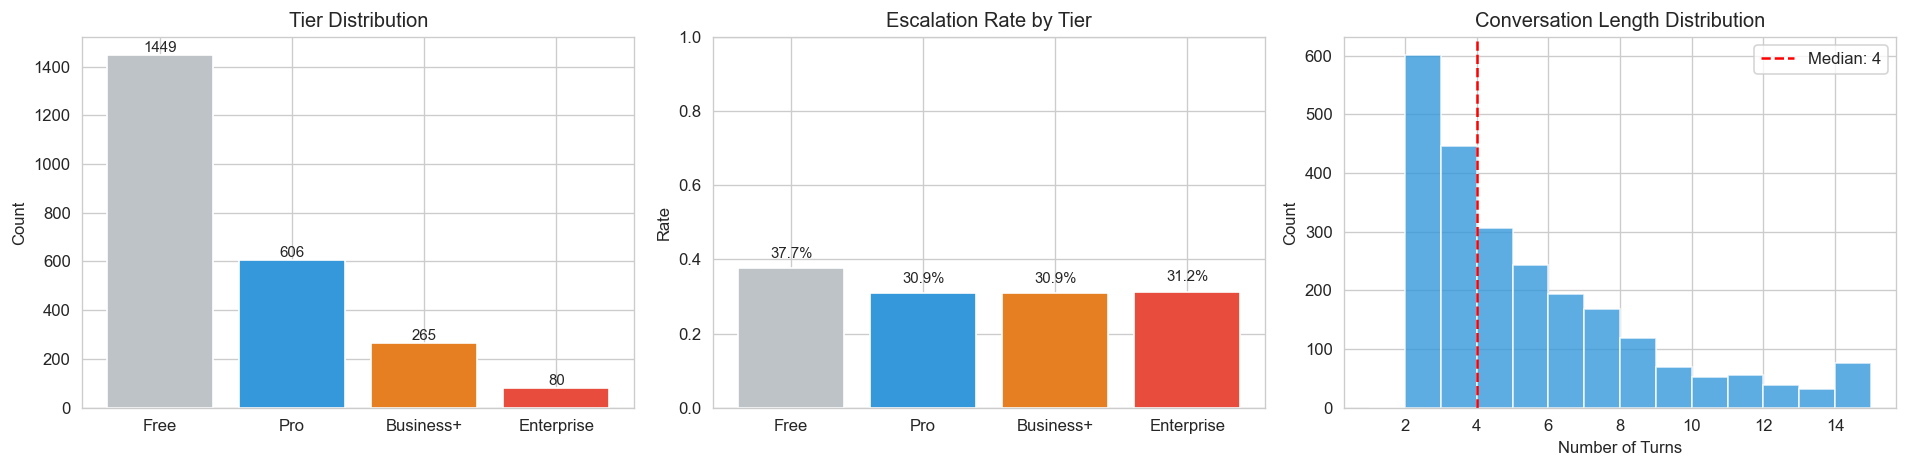


Overall escalation rate: 35.0%
Median conversation length: 4 turns
Sources: {'synthetic': 2400}


In [23]:
# ─── Dataset Exploration ───
conv_df = pd.DataFrame(train_convs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Tier distribution
ax = axes[0]
tier_counts = conv_df['tier'].value_counts()
tier_counts = tier_counts.reindex(TIER_NAMES)
bars = ax.bar(tier_counts.index, tier_counts.values,
              color=[TIER_COLORS.get(t, 'gray') for t in tier_counts.index])
ax.set_title('Tier Distribution')
ax.set_ylabel('Count')
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val}', ha='center', va='bottom', fontsize=9)

# 2. Escalation rate by tier
ax = axes[1]
esc_by_tier = conv_df.groupby('tier')['escalation_needed'].mean().reindex(TIER_NAMES)
bars = ax.bar(esc_by_tier.index, esc_by_tier.values,
              color=[TIER_COLORS.get(t, 'gray') for t in esc_by_tier.index])
ax.set_title('Escalation Rate by Tier')
ax.set_ylabel('Rate')
ax.set_ylim(0, 1)
for bar, val in zip(bars, esc_by_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)

# 3. Conversation length distribution
ax = axes[2]
ax.hist(conv_df['num_turns'], bins=range(1, 16), color='#3498db',
        edgecolor='white', alpha=0.8)
ax.axvline(conv_df['num_turns'].median(), color='red', linestyle='--',
           label=f'Median: {conv_df["num_turns"].median():.0f}')
ax.set_title('Conversation Length Distribution')
ax.set_xlabel('Number of Turns')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nOverall escalation rate: {conv_df['escalation_needed'].mean():.1%}")
print(f"Median conversation length: {conv_df['num_turns'].median():.0f} turns")
print(f"Sources: {conv_df['source'].value_counts().to_dict()}")

## 2. Economically Optimal Escalation Thresholds

The central decision rule from the AML proposal:

$$\text{Escalate if } \; p \times \underbrace{E[\text{Churn Cost}]}_{\text{churn\_prob} \times \text{CLV}} > \underbrace{C_{\text{escalation}}}_{\text{tier-specific}}$$

The optimal **threshold** $\tau$ for each tier:

$$\tau_{\text{tier}} = \frac{C_{\text{escalation}}}{\text{churn\_prob} \times \text{CLV}}$$

Conversations with estimated failure probability $p > \tau$ should be escalated to a human agent.

Economically Optimal Escalation Thresholds:
  Free         | Threshold: 1.0000 | Esc Cost: ₹   0 | Churn Cost: ₹       0
  Pro          | Threshold: 0.0465 | Esc Cost: ₹  15 | Churn Cost: ₹     323
  Business+    | Threshold: 0.1297 | Esc Cost: ₹  50 | Churn Cost: ₹     386
  Enterprise   | Threshold: 0.1736 | Esc Cost: ₹ 100 | Churn Cost: ₹     576

Interpretation:
  Lower threshold → escalate more aggressively (protect high-CLV customers)
  Higher threshold → deflect more (cost-efficient for low-value tiers)


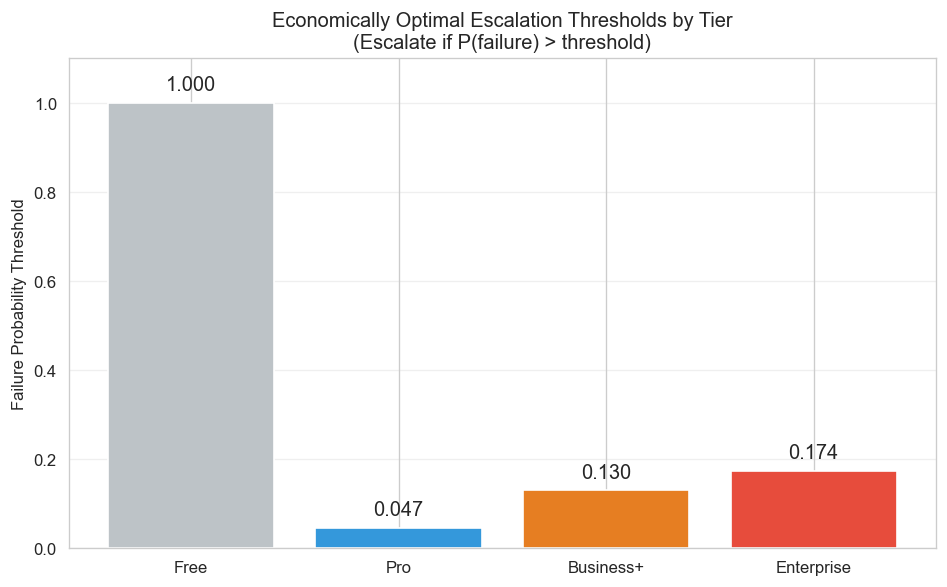

In [24]:
# ─── Compute & Visualize Thresholds ───
thresholds = get_all_thresholds()

print("Economically Optimal Escalation Thresholds:")
print("=" * 55)
for tier in TIER_NAMES:
    cfg = TIER_CONFIG[tier]
    t = thresholds[tier]
    ecl = cfg['churn_prob_bad_exp'] * cfg['clv']
    print(f"  {tier:12s} | Threshold: {t:.4f} | "
          f"Esc Cost: ₹{cfg['escalation_cost']:>4d} | "
          f"Churn Cost: ₹{ecl:>8,.0f}")

print("\nInterpretation:")
print("  Lower threshold → escalate more aggressively (protect high-CLV customers)")
print("  Higher threshold → deflect more (cost-efficient for low-value tiers)")

# Plot
plot_escalation_thresholds()

## 3. Phase I — Contextual Bandit Training

We compare three routing agents:

| Agent | Algorithm | Strength | Business Use |
|-------|-----------|----------|--------------|
| Rule-Based | Hard-coded tier rules | Interpretable | Baseline |
| LinUCB | Upper Confidence Bound | Efficient, <100ms | Free/Pro |
| Thompson Sampling | Bayesian posterior sampling | Adapts well | All tiers |

Each agent observes a **23-dimensional context vector** (sentiment, complexity, tier economics, turn features) and decides: **bot** (action 0) or **human** (action 1).

In [25]:
# ─── Train All Bandit Agents ───
print("Training Phase I: Contextual Bandits")
print("=" * 60)

# Rule-Based Baseline
print("\n[1/3] Rule-Based Baseline")
env_rule = CustomerSupportEnv(mode="bandit", conversations=train_convs, seed=SEED)
rule_agent = RuleBasedAgent(feature_dim=FEATURE_DIM)
results_rule = train_bandit(rule_agent, env_rule, n_episodes=N_EPISODES,
                            eval_every=500, verbose=True)

# LinUCB
print("\n[2/3] LinUCB (α=1.0)")
env_linucb = CustomerSupportEnv(mode="bandit", conversations=train_convs, seed=SEED)
linucb_agent = LinUCBAgent(feature_dim=FEATURE_DIM, alpha=1.0)
results_linucb = train_bandit(linucb_agent, env_linucb, n_episodes=N_EPISODES,
                              eval_every=500, verbose=True)

# Thompson Sampling
print("\n[3/3] Thompson Sampling")
env_ts = CustomerSupportEnv(mode="bandit", conversations=train_convs, seed=SEED)
ts_agent = ThompsonSamplingAgent(feature_dim=FEATURE_DIM, v_squared=0.5)
results_ts = train_bandit(ts_agent, env_ts, n_episodes=N_EPISODES,
                          eval_every=500, verbose=True)

# Collect results
bandit_results = {
    'rule_based': results_rule,
    'linucb': results_linucb,
    'thompson_sampling': results_ts,
}

Training Phase I: Contextual Bandits

[1/3] Rule-Based Baseline
  Episode   500 | Avg Reward: +1.707 | Bot/Human: 0.98/0.02 | Time: 0.1s
  Episode  1000 | Avg Reward: +2.010 | Bot/Human: 0.97/0.03 | Time: 0.1s
  Episode  1500 | Avg Reward: +1.779 | Bot/Human: 0.97/0.03 | Time: 0.1s
  Episode  2000 | Avg Reward: +1.890 | Bot/Human: 0.97/0.03 | Time: 0.2s
  Episode  2500 | Avg Reward: +1.771 | Bot/Human: 0.97/0.03 | Time: 0.3s
  Episode  3000 | Avg Reward: +1.837 | Bot/Human: 0.97/0.03 | Time: 0.3s

  Training complete in 0.3s
  Final avg reward: +1.837

[2/3] LinUCB (α=1.0)
  Episode   500 | Avg Reward: +2.178 | Bot/Human: 0.24/0.76 | Time: 0.1s
  Episode  1000 | Avg Reward: +2.149 | Bot/Human: 0.25/0.75 | Time: 0.2s
  Episode  1500 | Avg Reward: +2.326 | Bot/Human: 0.25/0.75 | Time: 0.2s
  Episode  2000 | Avg Reward: +2.172 | Bot/Human: 0.25/0.75 | Time: 0.3s
  Episode  2500 | Avg Reward: +2.236 | Bot/Human: 0.24/0.76 | Time: 0.4s
  Episode  3000 | Avg Reward: +2.236 | Bot/Human: 0.24/

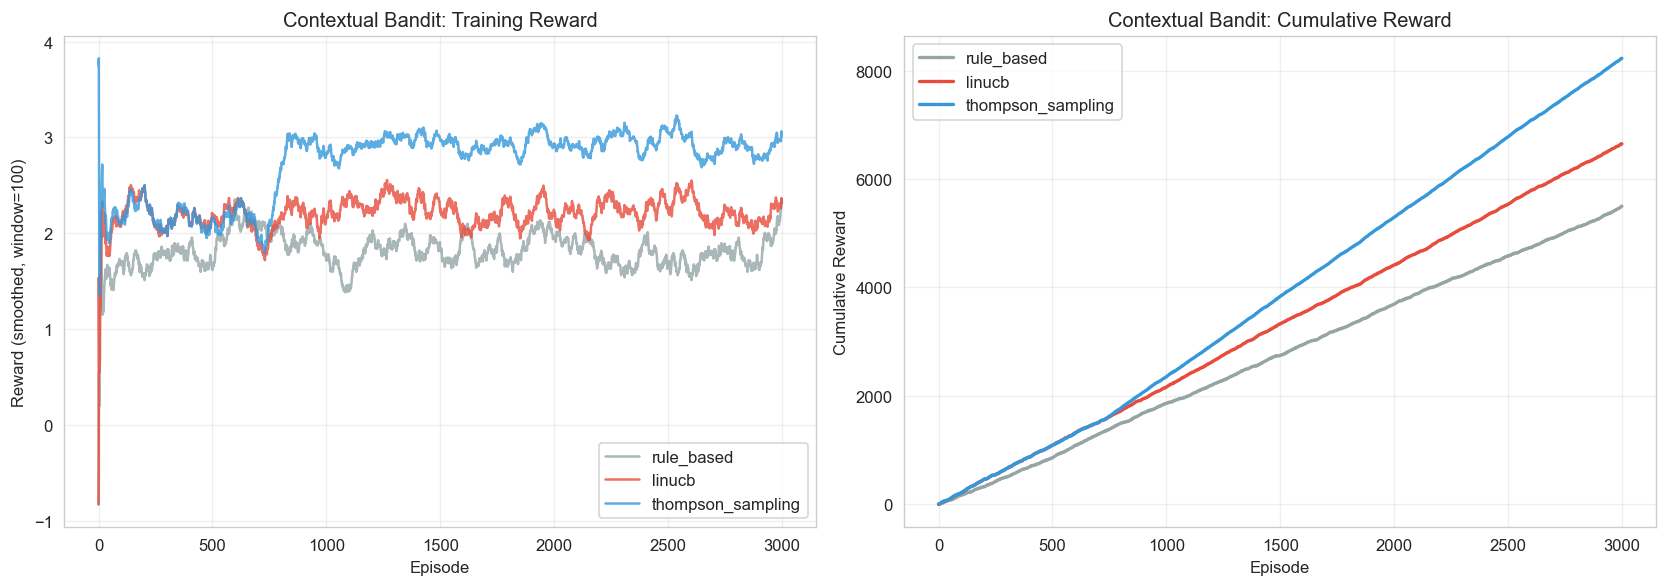

In [26]:
# ─── Bandit Training Curves ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Smoothed reward over time
ax = axes[0]
window = 100
for name, color in [('rule_based', COLORS['rule_based']),
                     ('linucb', COLORS['linucb']),
                     ('thompson_sampling', COLORS['thompson_sampling'])]:
    rewards = bandit_results[name]['rewards']
    smoothed = pd.Series(rewards).rolling(window, min_periods=1).mean()
    ax.plot(smoothed, label=name, color=color, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Episode')
ax.set_ylabel(f'Reward (smoothed, window={window})')
ax.set_title('Contextual Bandit: Training Reward')
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative reward
ax = axes[1]
for name, color in [('rule_based', COLORS['rule_based']),
                     ('linucb', COLORS['linucb']),
                     ('thompson_sampling', COLORS['thompson_sampling'])]:
    cumulative = np.cumsum(bandit_results[name]['rewards'])
    ax.plot(cumulative, label=name, color=color, linewidth=2)

ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Contextual Bandit: Cumulative Reward')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Phase II — Full RL (DQN)

For Business+/Enterprise tiers, we model the dialogue as a **Markov Decision Process**:

$$\mathcal{M} = \langle S, A, P, R, \gamma \rangle$$

Actions = {ask\_info, provide\_solution, escalate, close}

The reward function explicitly encodes business costs:

$$R_t = +\alpha \cdot \mathbf{1}_{\text{Resolved}} - C_{\text{esc}} \cdot \mathbf{1}_{\text{Escalate}} - L_{\text{churn}} \cdot \mathbf{1}_{\text{Failure}} - \delta \cdot \text{TurnPenalty}$$

In [27]:
# ─── Train DQN Agent ───
print("Training Phase II: DQN (MDP)")
print("=" * 60)

env_dqn = CustomerSupportEnv(mode="mdp", conversations=train_convs, seed=SEED)
dqn_agent = DQNAgent(feature_dim=FEATURE_DIM)
results_dqn = train_dqn(dqn_agent, env_dqn, n_episodes=N_EPISODES,
                        eval_every=500, verbose=True)

bandit_results['dqn'] = results_dqn

Training Phase II: DQN (MDP)
  Episode   500 | Avg Reward: +26.060 | Avg Length: 14.0 | Epsilon: 0.050 | Loss: 3831.8410
  Episode  1000 | Avg Reward: +32.719 | Avg Length: 15.7 | Epsilon: 0.050 | Loss: 8569.0139
  Episode  1500 | Avg Reward: +28.579 | Avg Length: 15.7 | Epsilon: 0.050 | Loss: 2552.8298
  Episode  2000 | Avg Reward: +29.606 | Avg Length: 14.4 | Epsilon: 0.050 | Loss: 777.4981
  Episode  2500 | Avg Reward: +28.087 | Avg Length: 12.4 | Epsilon: 0.050 | Loss: 377.9756
  Episode  3000 | Avg Reward: +32.003 | Avg Length: 15.8 | Epsilon: 0.050 | Loss: 962.5323


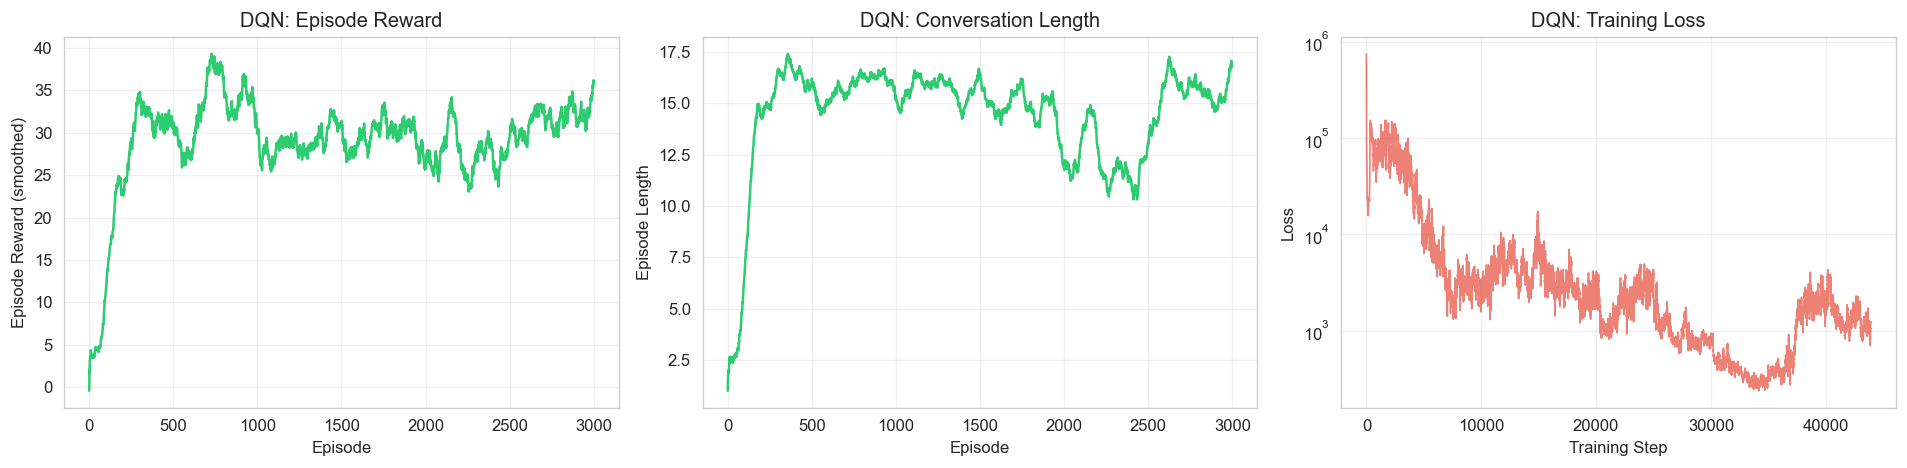


DQN Final Stats:
  Epsilon: 0.0500
  Avg reward (last 500): +32.003
  Avg length (last 500): 15.8
  Action distribution: [0.22021144 0.73634193 0.02132545 0.02212118]


In [28]:
# ─── DQN Training Curves ───
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Episode reward
ax = axes[0]
ep_rewards = results_dqn['episode_rewards']
smoothed = pd.Series(ep_rewards).rolling(100, min_periods=1).mean()
ax.plot(smoothed, color=COLORS['dqn'], linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Reward (smoothed)')
ax.set_title('DQN: Episode Reward')
ax.grid(True, alpha=0.3)

# Episode length
ax = axes[1]
ep_lengths = results_dqn['episode_lengths']
smoothed_len = pd.Series(ep_lengths).rolling(100, min_periods=1).mean()
ax.plot(smoothed_len, color=COLORS['dqn'], linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Length')
ax.set_title('DQN: Conversation Length')
ax.grid(True, alpha=0.3)

# Loss
ax = axes[2]
if results_dqn['losses']:
    losses = pd.Series(results_dqn['losses']).rolling(50, min_periods=1).mean()
    ax.plot(losses, color='#e74c3c', linewidth=1, alpha=0.7)
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Loss')
    ax.set_title('DQN: Training Loss')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDQN Final Stats:")
policy = dqn_agent.get_policy_info()
print(f"  Epsilon: {policy['epsilon']:.4f}")
print(f"  Avg reward (last 500): {np.mean(ep_rewards[-500:]):+.3f}")
print(f"  Avg length (last 500): {np.mean(ep_lengths[-500:]):.1f}")
print(f"  Action distribution: {policy['action_distribution']}")

## 5. Business-Aligned Evaluation

Primary metric: **Expected Monthly Cost Reduction**

$$\text{CostSaved} = (\delta \cdot \bar{C}_{\text{esc}} \cdot V) - (C_{\text{inf}} \cdot V) - C_{\text{churn}}$$

Secondary metrics: correct routing rate, tier-specific escalation rates, CSAT proxy.

In [30]:

# ─── Force reload fixed metrics module, then compare ───
import importlib
import evaluation.metrics as _em
importlib.reload(_em)
from evaluation.metrics import compute_business_metrics, generate_comparison_table

print("Agent Comparison — Business Metrics")
print("=" * 75)
print(generate_comparison_table(bandit_results))

# Detailed metrics per agent
print("\n\nDetailed Metrics:")
for name in ['rule_based', 'linucb', 'thompson_sampling']:
    metrics = compute_business_metrics(bandit_results[name])
    print(f"\n  {name}:")
    print(f"    Avg Reward:           {metrics['avg_reward']:+.4f}")
    print(f"    Escalation Rate:      {metrics['escalation_rate']:.1%}")
    print(f"    Correct Routing:      {metrics['correct_routing_rate']:.1%}")
    print(f"    Missed Escalations:   {metrics['missed_escalation_rate']:.1%}")
    print(f"    Unnecessary Esc.:     {metrics['unnecessary_escalation_rate']:.1%}")
    print(f"    Est. Cost Saved/conv: ₹{metrics['estimated_cost_savings_per_conv']:.1f}")


Agent Comparison — Business Metrics
Agent                Avg Reward   Esc Rate  Correct %     Missed  Unnecessary
-----------------------------------------------------------------------------
rule_based               +1.832       2.8%      67.7%      32.3%         0.0%
linucb                   +2.216      75.6%      57.1%       1.2%        41.7%
thompson_sampling        +2.741      51.6%      80.3%       1.6%        18.1%
dqn                     +29.509       7.2%       0.0%       0.0%         0.0%


Detailed Metrics:

  rule_based:
    Avg Reward:           +1.8324
    Escalation Rate:      2.8%
    Correct Routing:      67.7%
    Missed Escalations:   32.3%
    Unnecessary Esc.:     0.0%
    Est. Cost Saved/conv: ₹91.6

  linucb:
    Avg Reward:           +2.2164
    Escalation Rate:      75.6%
    Correct Routing:      57.1%
    Missed Escalations:   1.2%
    Unnecessary Esc.:     41.7%
    Est. Cost Saved/conv: ₹110.8

  thompson_sampling:
    Avg Reward:           +2.7415
    Esca

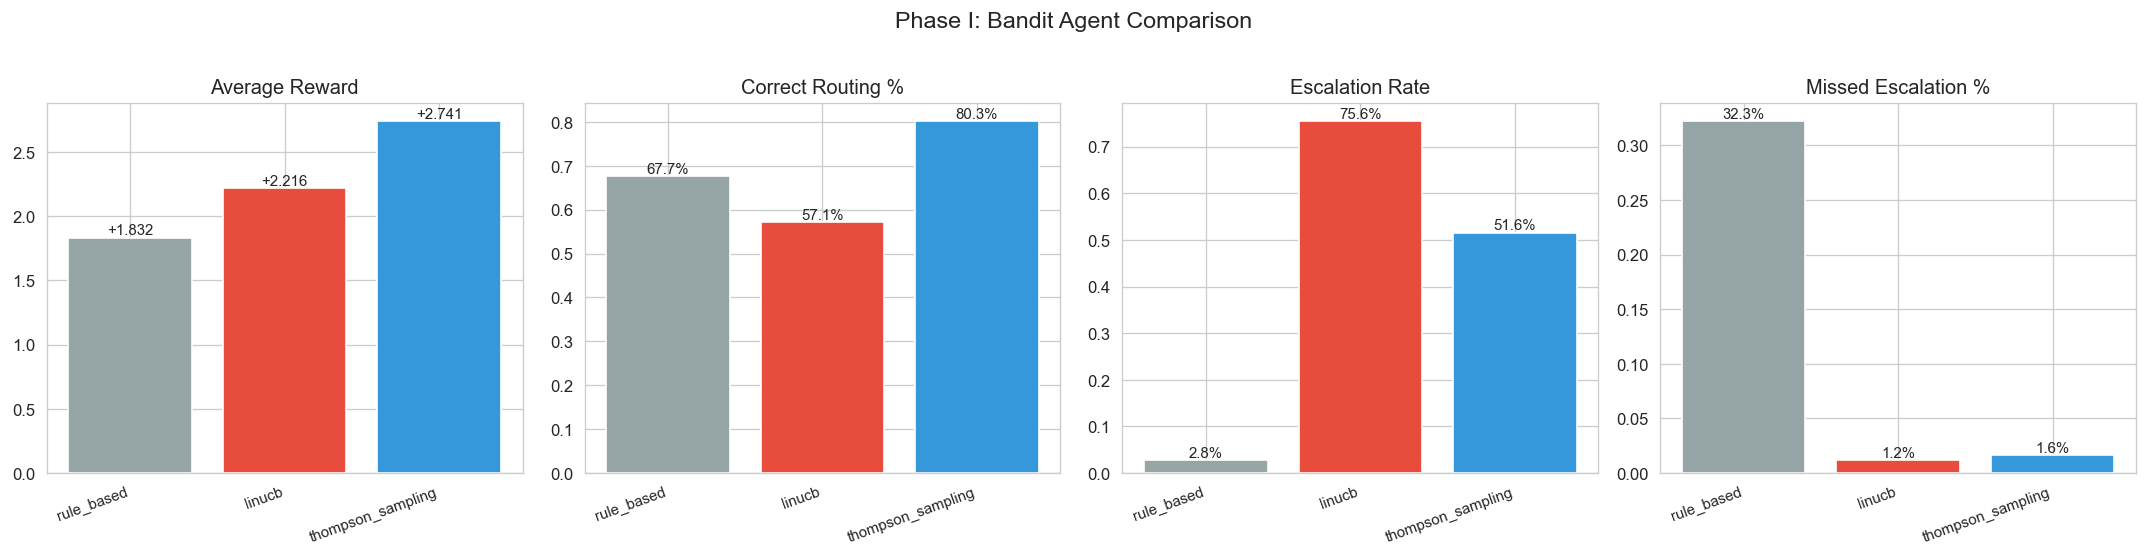

In [31]:
# ─── Agent Comparison Bar Charts ───
agents = ['rule_based', 'linucb', 'thompson_sampling']
metrics_list = [compute_business_metrics(bandit_results[a]) for a in agents]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

metric_keys = ['avg_reward', 'correct_routing_rate', 'escalation_rate', 'missed_escalation_rate']
metric_labels = ['Average Reward', 'Correct Routing %', 'Escalation Rate', 'Missed Escalation %']

for ax, key, label in zip(axes, metric_keys, metric_labels):
    values = [m[key] for m in metrics_list]
    bars = ax.bar(agents, values, color=[COLORS.get(a, 'gray') for a in agents])
    ax.set_title(label)
    ax.set_xticklabels(agents, rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, values):
        fmt = f'{val:+.3f}' if 'reward' in key.lower() else f'{val:.1%}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt, ha='center', va='bottom', fontsize=9)

plt.suptitle('Phase I: Bandit Agent Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Tier-Stratified Evaluation

Agent: linucb
Tier              N   Avg Reward   Esc Rate    Correct  Threshold
--------------------------------------------------------------
Free            369       +1.607     100.0%      36.3%        2% ✗
Pro             132       +2.796      43.9%      85.6%       15% ✗
Business+        76       +3.294      36.8%      88.2%       30% ✗
Enterprise       23       +4.978      21.7%     100.0%       50% ✓


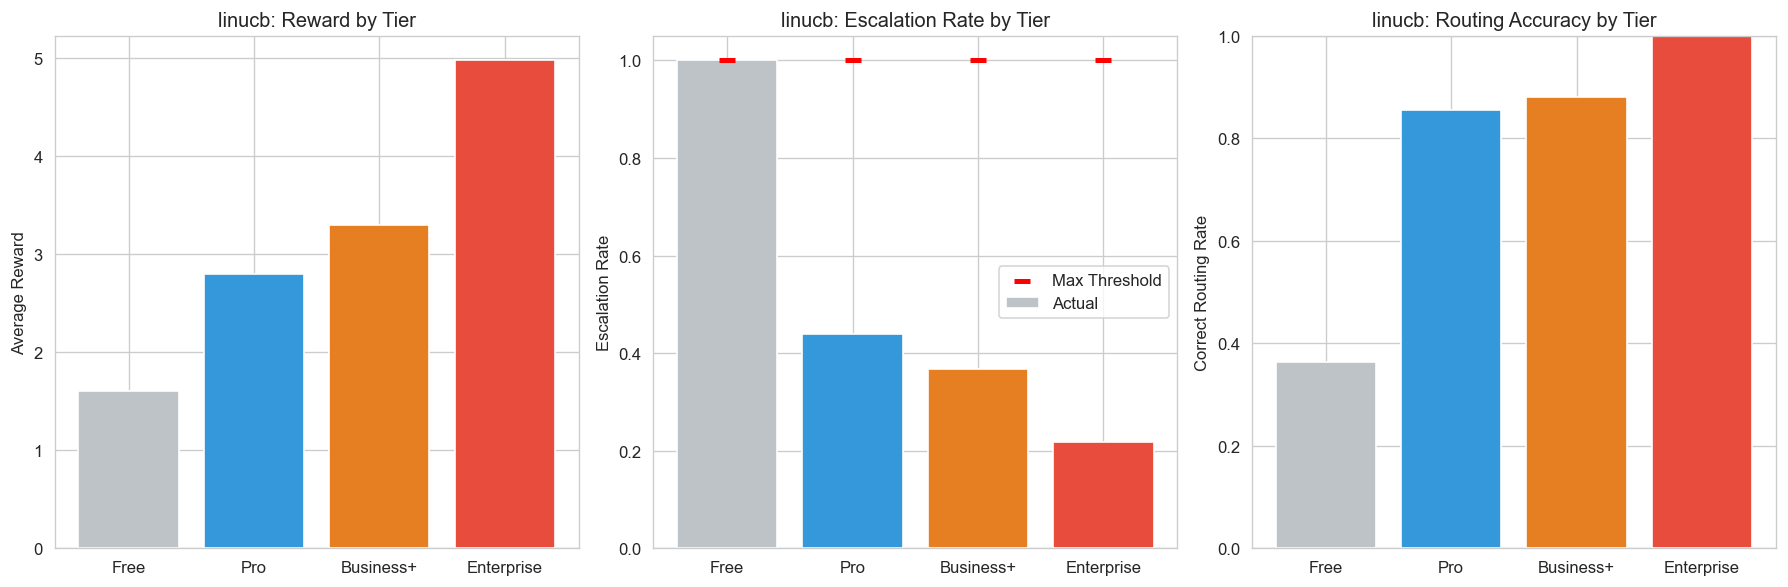

In [32]:
# ─── Tier-Stratified Evaluation ───
print("Tier-Stratified Evaluation")
print("=" * 70)

eval_env = CustomerSupportEnv(mode="bandit", conversations=eval_convs, seed=SEED)

best_agent_name = 'linucb'
best_agent = linucb_agent

tier_metrics = evaluate_on_tiers(best_agent, eval_env, n_eval=len(eval_convs))

# Print results
print(f"\nAgent: {best_agent_name}")
print(f"{'Tier':<12} {'N':>6} {'Avg Reward':>12} {'Esc Rate':>10} {'Correct':>10} {'Threshold':>10}")
print("-" * 62)
for tier in TIER_NAMES:
    if tier in tier_metrics:
        m = tier_metrics[tier]
        t_max = TIER_CONFIG[tier]['max_escalation_rate']
        within = "✓" if m['escalation_rate'] <= t_max else "✗"
        print(f"{tier:<12} {m['n_conversations']:>6} "
              f"{m['avg_reward']:>+12.3f} "
              f"{m['escalation_rate']:>10.1%} "
              f"{m['correct_routing_rate']:>10.1%} "
              f"{t_max:>9.0%} {within}")

# Visualize
plot_tier_performance(tier_metrics, agent_name=best_agent_name)

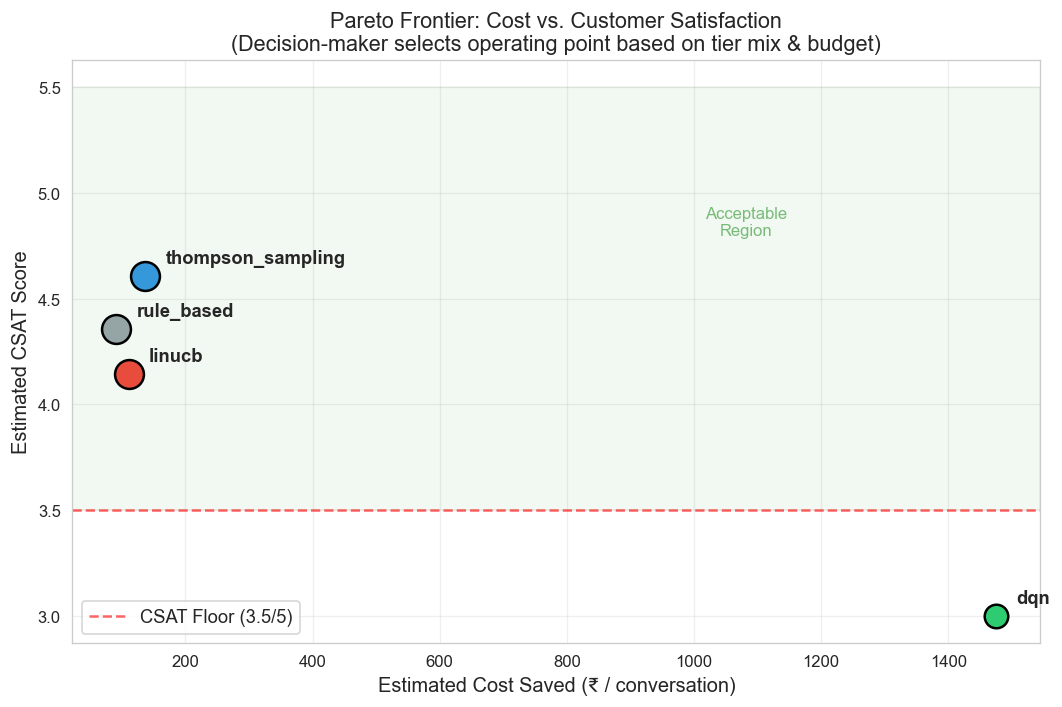


Pareto Points:
  rule_based           | Cost: ₹   91.6 | CSAT: 4.35 | Esc: 2.8%
  linucb               | Cost: ₹  110.8 | CSAT: 4.14 | Esc: 75.6%
  thompson_sampling    | Cost: ₹  137.1 | CSAT: 4.61 | Esc: 51.6%
  dqn                  | Cost: ₹ 1475.4 | CSAT: 3.00 | Esc: 7.2%


In [33]:
# ─── Pareto Frontier: Cost Saved vs. CSAT ───
pareto_points = compute_pareto_metrics(bandit_results)

fig, ax = plt.subplots(figsize=(9, 6))

for p in pareto_points:
    color = COLORS.get(p['agent'], 'gray')
    size = 300 if p['agent'] != 'dqn' else 200
    ax.scatter(p['cost_saved'], p['csat'], color=color, s=size,
               zorder=5, edgecolors='black', linewidth=1.5)
    ax.annotate(p['agent'], (p['cost_saved'], p['csat']),
                textcoords="offset points", xytext=(12, 8),
                fontsize=11, fontweight='bold')

# CSAT floor
ax.axhline(y=3.5, color='red', linestyle='--', alpha=0.6,
           label='CSAT Floor (3.5/5)', linewidth=1.5)

# Shade acceptable region
ax.axhspan(3.5, 5.5, alpha=0.05, color='green')
ax.text(ax.get_xlim()[1] * 0.7, 4.8, 'Acceptable\nRegion',
        fontsize=10, color='green', alpha=0.5, ha='center')

ax.set_xlabel('Estimated Cost Saved (₹ / conversation)', fontsize=12)
ax.set_ylabel('Estimated CSAT Score', fontsize=12)
ax.set_title('Pareto Frontier: Cost vs. Customer Satisfaction\n'
             '(Decision-maker selects operating point based on tier mix & budget)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPareto Points:")
for p in pareto_points:
    print(f"  {p['agent']:20s} | Cost: ₹{p['cost_saved']:>7.1f} | "
          f"CSAT: {p['csat']:.2f} | Esc: {p['escalation_rate']:.1%}")

## 6. Sensitivity Analysis

The proposal specifies sensitivity analysis over three key parameters:
1. **CSA Cost** (±20%) — "High-sensitivity assumption"
2. **Churn Elasticity** — "High uncertainty, huge impact"
3. **Cost Ratio** $C_{\text{CSA}} / C_{\text{inf}} \in [10, 100]$ — Affects model choice

Plus a **Go/No-Go** deployment decision:

> If $(CostSaved/user \times Users \times 12) > (MLCost + InfCost)$ and $\Delta CSAT > -0.1$, scale to 50% traffic.

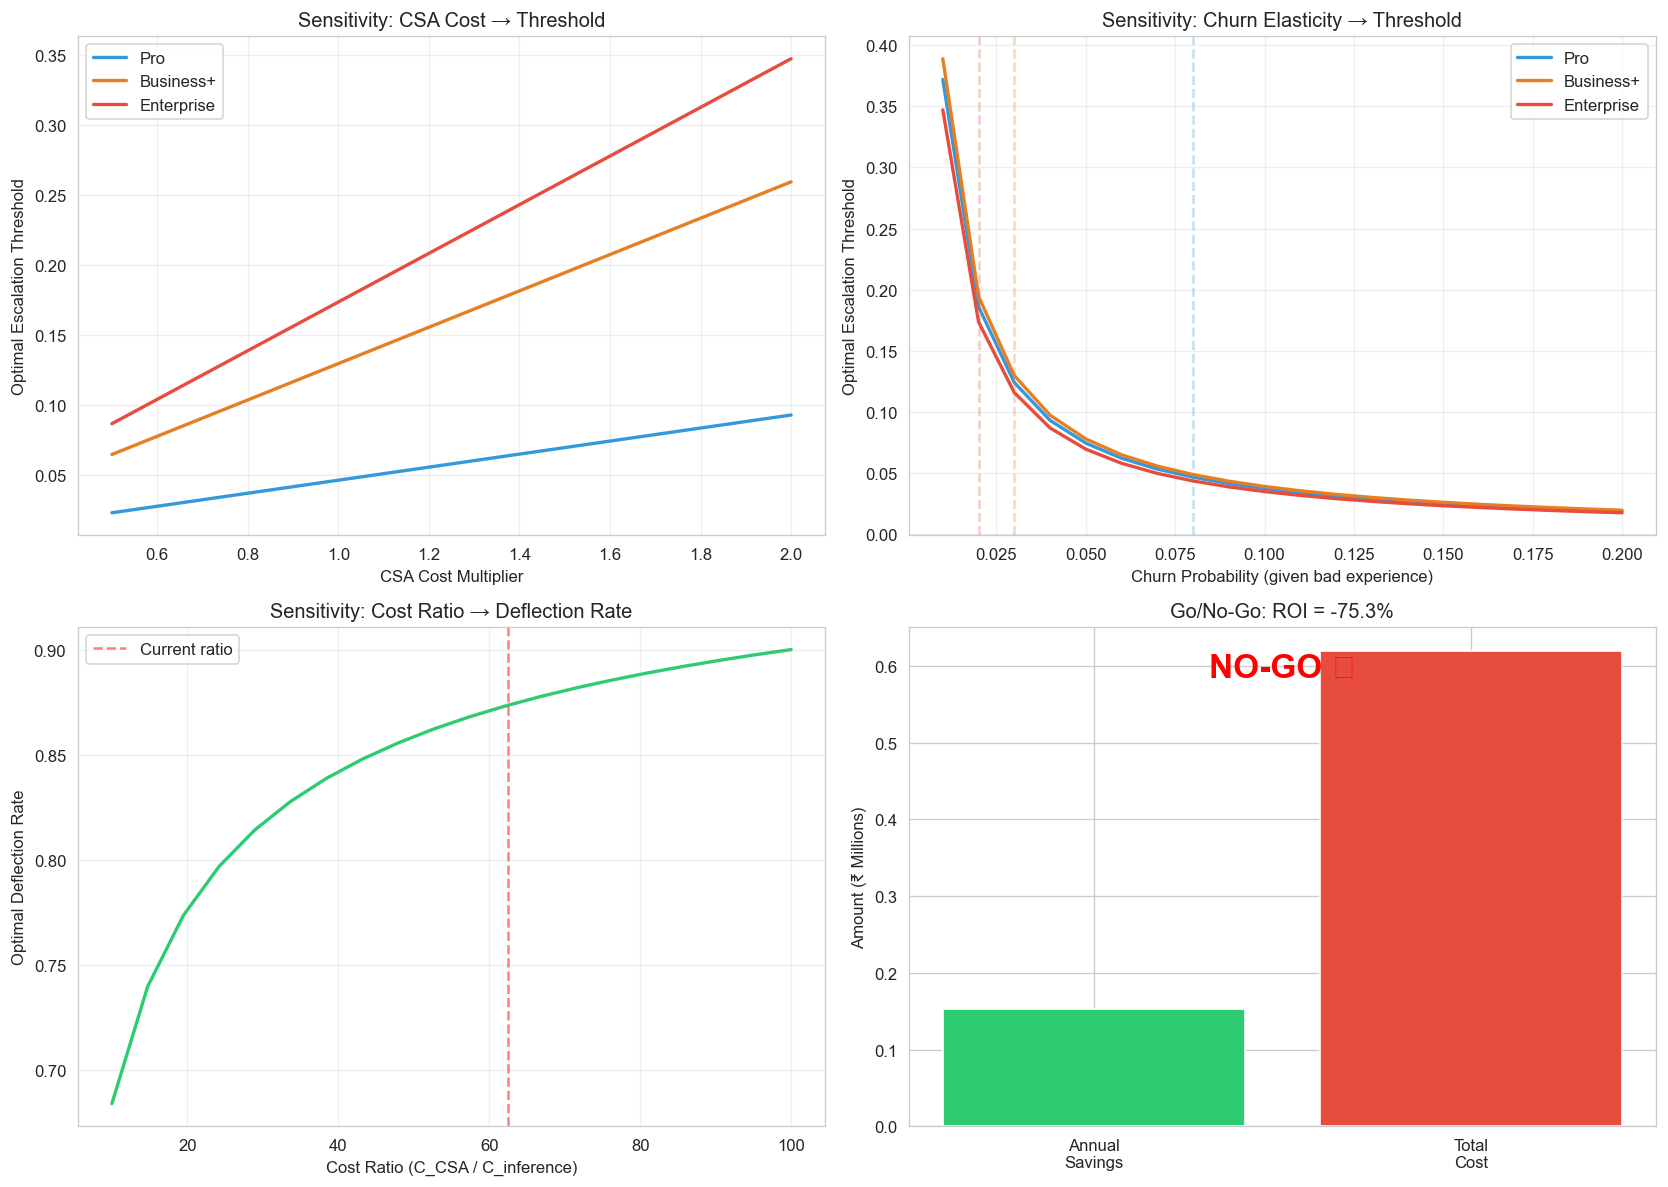

In [34]:
# ─── Run Full Sensitivity Analysis ───
sensitivity = run_full_sensitivity(tiers=['Pro', 'Business+', 'Enterprise'])

# Plot all sensitivity curves
plot_sensitivity_curves(sensitivity)

In [35]:
# ─── Go/No-Go Deployment Assessment ───
go_data = sensitivity['go_no_go']

print("=" * 55)
print("  GO / NO-GO DEPLOYMENT ASSESSMENT")
print("=" * 55)
print(f"  Estimated savings / user / month:  ₹{go_data['estimated_savings_per_user_month']:.2f}")
print(f"  Annual savings (10K users):        ₹{go_data['annual_savings']:>12,.0f}")
print(f"  ML development cost (one-time):    ₹{go_data['total_cost'] - 120000:>12,.0f}")
print(f"  Annual infrastructure cost:        ₹{120000:>12,.0f}")
print(f"  Total cost:                        ₹{go_data['total_cost']:>12,.0f}")
print(f"  ─────────────────────────────────────────────")
print(f"  ROI:                               {go_data['roi']:>12.1%}")
print(f"  Payback period:                    {go_data['payback_months']:>12.1f} months")
print(f"  Breakeven users:                   {go_data['breakeven_users']:>12,}")
print(f"  ─────────────────────────────────────────────")

decision = "✅ GO — Deploy to 50% traffic" if go_data['go_decision'] else "❌ NO-GO — Insufficient ROI"
print(f"  DECISION: {decision}")
print(f"=" * 55)

  GO / NO-GO DEPLOYMENT ASSESSMENT
  Estimated savings / user / month:  ₹1.27
  Annual savings (10K users):        ₹     153,000
  ML development cost (one-time):    ₹     500,000
  Annual infrastructure cost:        ₹     120,000
  Total cost:                        ₹     620,000
  ─────────────────────────────────────────────
  ROI:                                     -75.3%
  Payback period:                            48.6 months
  Breakeven users:                         40,522
  ─────────────────────────────────────────────
  DECISION: ❌ NO-GO — Insufficient ROI


## 7. Capacity Allocation — Priority Ranking

For the top-$K$ human slots per hour, we rank conversations by priority:

$$\text{Priority} = \text{EscRisk} \times (\text{CLV} - C_{\text{int}}) \times (1 - \text{CSAT}/5)$$

Top-$K$ get human agents; the rest are routed to the bot.

Capacity Allocation (K=50 human slots/hour):
  Conversations scored: 200
  Routed to human: 50 (top-K by priority)
  Routed to bot:   150

Top-K tier breakdown:
tier
Business+     21
Pro           21
Enterprise     8

Top-K escalation capture rate: 46.0% (vs 31.5% overall)


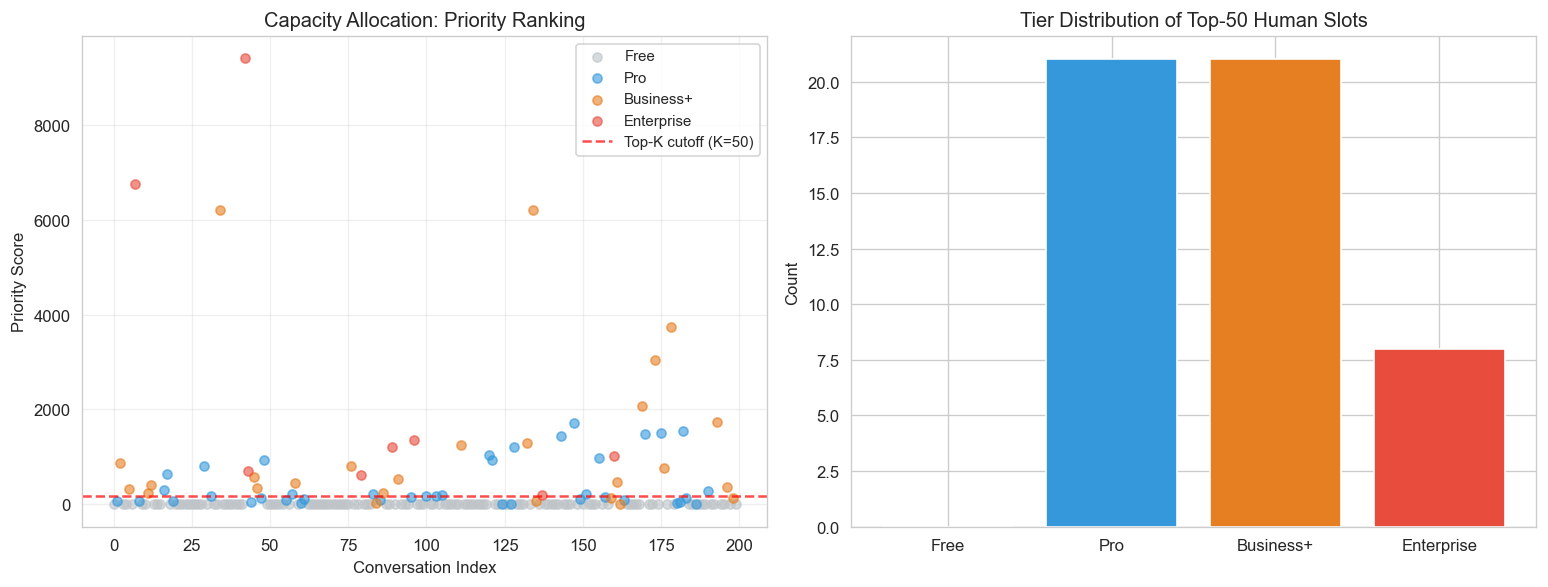

In [36]:
# ─── Priority Scoring Example ───
K = 50  # Human slots per hour

# Score a batch of conversations
priorities = []
for conv in eval_convs[:200]:
    tier = conv['tier']
    cfg = TIER_CONFIG[tier]
    esc_risk = conv.get('escalation_needed', 0) * 0.8 + 0.2 * np.random.random()

    priority = compute_priority_score(
        escalation_risk=esc_risk,
        clv=cfg['clv'],
        interaction_cost=cfg['escalation_cost'],
        csat=3.5 + np.random.normal(0, 0.5),
    )
    priorities.append({
        'conversation_id': conv['conversation_id'],
        'tier': tier,
        'escalation_risk': esc_risk,
        'priority': priority,
        'escalation_needed': conv['escalation_needed'],
    })

priority_df = pd.DataFrame(priorities).sort_values('priority', ascending=False)

# Top-K get human agents
top_k = priority_df.head(K)
bottom = priority_df.iloc[K:]

print(f"Capacity Allocation (K={K} human slots/hour):")
print(f"  Conversations scored: {len(priority_df)}")
print(f"  Routed to human: {len(top_k)} (top-K by priority)")
print(f"  Routed to bot:   {len(bottom)}")
print(f"\nTop-K tier breakdown:")
print(top_k['tier'].value_counts().to_string())
print(f"\nTop-K escalation capture rate: "
      f"{top_k['escalation_needed'].mean():.1%} "
      f"(vs {priority_df['escalation_needed'].mean():.1%} overall)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for tier in TIER_NAMES:
    mask = priority_df['tier'] == tier
    tier_data = priority_df[mask]
    ax.scatter(tier_data.index, tier_data['priority'],
               color=TIER_COLORS.get(tier, 'gray'), s=30, alpha=0.6, label=tier)
ax.axhline(y=priority_df.iloc[K-1]['priority'] if len(priority_df) >= K else 0,
           color='red', linestyle='--', alpha=0.7, label=f'Top-K cutoff (K={K})')
ax.set_xlabel('Conversation Index')
ax.set_ylabel('Priority Score')
ax.set_title('Capacity Allocation: Priority Ranking')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
top_k_tiers = top_k['tier'].value_counts().reindex(TIER_NAMES, fill_value=0)
ax.bar(top_k_tiers.index, top_k_tiers.values,
       color=[TIER_COLORS.get(t, 'gray') for t in top_k_tiers.index])
ax.set_title(f'Tier Distribution of Top-{K} Human Slots')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 8. Optional: Gemini LLM-as-Judge Enrichment

If `GEMINI_API_KEY` is set, we use Gemini 2.0 Flash to:
- Score customer sentiment more accurately than rule-based
- Classify escalation risk using NLU
- Assess conversation quality

This refines the reward signal and provides better features for the bandit.

In [37]:
# ─── Gemini Enrichment (optional) ───
try:
    from gemini_utils import gemini_available, score_sentiment_gemini, classify_escalation_risk

    if gemini_available():
        print("Gemini API available ✓")

        # Demo: score a few example messages
        test_msgs = [
            "Your service has been terrible, I want a refund!",
            "Thanks for fixing that so quickly, great support!",
            "I've been waiting 3 days and nobody has responded.",
            "How do I change my password?",
        ]

        print("\nSentiment Scoring (Gemini LLM-as-judge):")
        print("-" * 60)
        for msg in test_msgs:
            result = score_sentiment_gemini(msg)
            print(f"  [{result['score']:+.2f} {result['label']:>8}] {msg[:60]}")

        print("\nEscalation Risk (Gemini):")
        print("-" * 60)
        esc = classify_escalation_risk(test_msgs[:2])
        print(f"  Probability: {esc['escalation_probability']:.2f}")
        print(f"  Risk level:  {esc['risk_level']}")
        print(f"  Signals:     {esc['signals']}")
        print(f"  Recommend:   {esc['recommended_action']}")
    else:
        print("⚠ Gemini API key not set.")
        print("  Set GEMINI_API_KEY environment variable to enable LLM enrichment.")
        print("  The system works fully without it using rule-based features.")

except ImportError:
    print("⚠ google-genai not installed. Run: pip install google-genai")
    print("  The system works fully without it using rule-based features.")

⚠ Gemini API key not set.
  Set GEMINI_API_KEY environment variable to enable LLM enrichment.
  The system works fully without it using rule-based features.


## 9. Monthly Profit Simulation

Simulate a full month of operations under each policy to compute economic impact.

In [38]:
# ─── Monthly Profit Simulation ───
monthly_volume = 10000  # Total monthly conversations

print("Monthly Profit Simulation (10,000 conversations)")
print("=" * 70)

for agent_name in ['rule_based', 'linucb', 'thompson_sampling']:
    metrics = compute_business_metrics(bandit_results[agent_name])

    tier_mix = {'Free': 0.60, 'Pro': 0.25, 'Business+': 0.12, 'Enterprise': 0.03}
    total_profit = 0
    total_esc_cost = 0
    total_churn_cost = 0

    print(f"\n  Agent: {agent_name}")
    print(f"  {'Tier':<12} {'Volume':>8} {'Profit':>12} {'Esc Cost':>10} {'Churn Cost':>12}")
    print(f"  {'-'*58}")

    for tier, frac in tier_mix.items():
        cfg = TIER_CONFIG[tier]
        vol = int(monthly_volume * frac)
        esc_count = int(vol * metrics['escalation_rate'])
        miss_rate = metrics['missed_escalation_rate']
        churn_count = int(vol * miss_rate * cfg['churn_prob_bad_exp'])

        profit = compute_monthly_profit(
            tier=tier,
            n_conversations=vol,
            n_escalated=esc_count,
            n_churned=churn_count,
            n_resolved=int(vol * metrics['correct_routing_rate']),
        )

        total_profit += profit['net_profit']
        total_esc_cost += profit['escalation_costs']
        total_churn_cost += profit['churn_costs']

        print(f"  {tier:<12} {vol:>8,} ₹{profit['net_profit']:>11,.0f} "
              f"₹{profit['escalation_costs']:>9,.0f} ₹{profit['churn_costs']:>11,.0f}")

    print(f"  {'-'*58}")
    print(f"  {'TOTAL':<12} {monthly_volume:>8,} ₹{total_profit:>11,.0f} "
          f"₹{total_esc_cost:>9,.0f} ₹{total_churn_cost:>11,.0f}")

Monthly Profit Simulation (10,000 conversations)

  Agent: rule_based
  Tier           Volume       Profit   Esc Cost   Churn Cost
  ----------------------------------------------------------
  Free            6,000 ₹   -124,664 ₹        0 ₹          0
  Pro             2,500 ₹    395,502 ₹    1,050 ₹     21,504
  Business+       1,200 ₹    413,986 ₹    1,700 ₹     11,781
  Enterprise        300 ₹    176,566 ₹      800 ₹      2,400
  ----------------------------------------------------------
  TOTAL          10,000 ₹    861,391 ₹    3,550 ₹     35,685

  Agent: linucb
  Tier           Volume       Profit   Esc Cost   Churn Cost
  ----------------------------------------------------------
  Free            6,000 ₹   -121,173 ₹        0 ₹          0
  Pro             2,500 ₹    390,504 ₹   28,335 ₹        672
  Business+       1,200 ₹    382,865 ₹   45,300 ₹          0
  Enterprise        300 ₹    157,341 ₹   22,600 ₹          0
  ---------------------------------------------------------

## 10. Feature Importance (LinUCB Weights)

LinUCB learns interpretable linear weights for each action. The magnitude of each weight indicates feature importance for the routing decision.

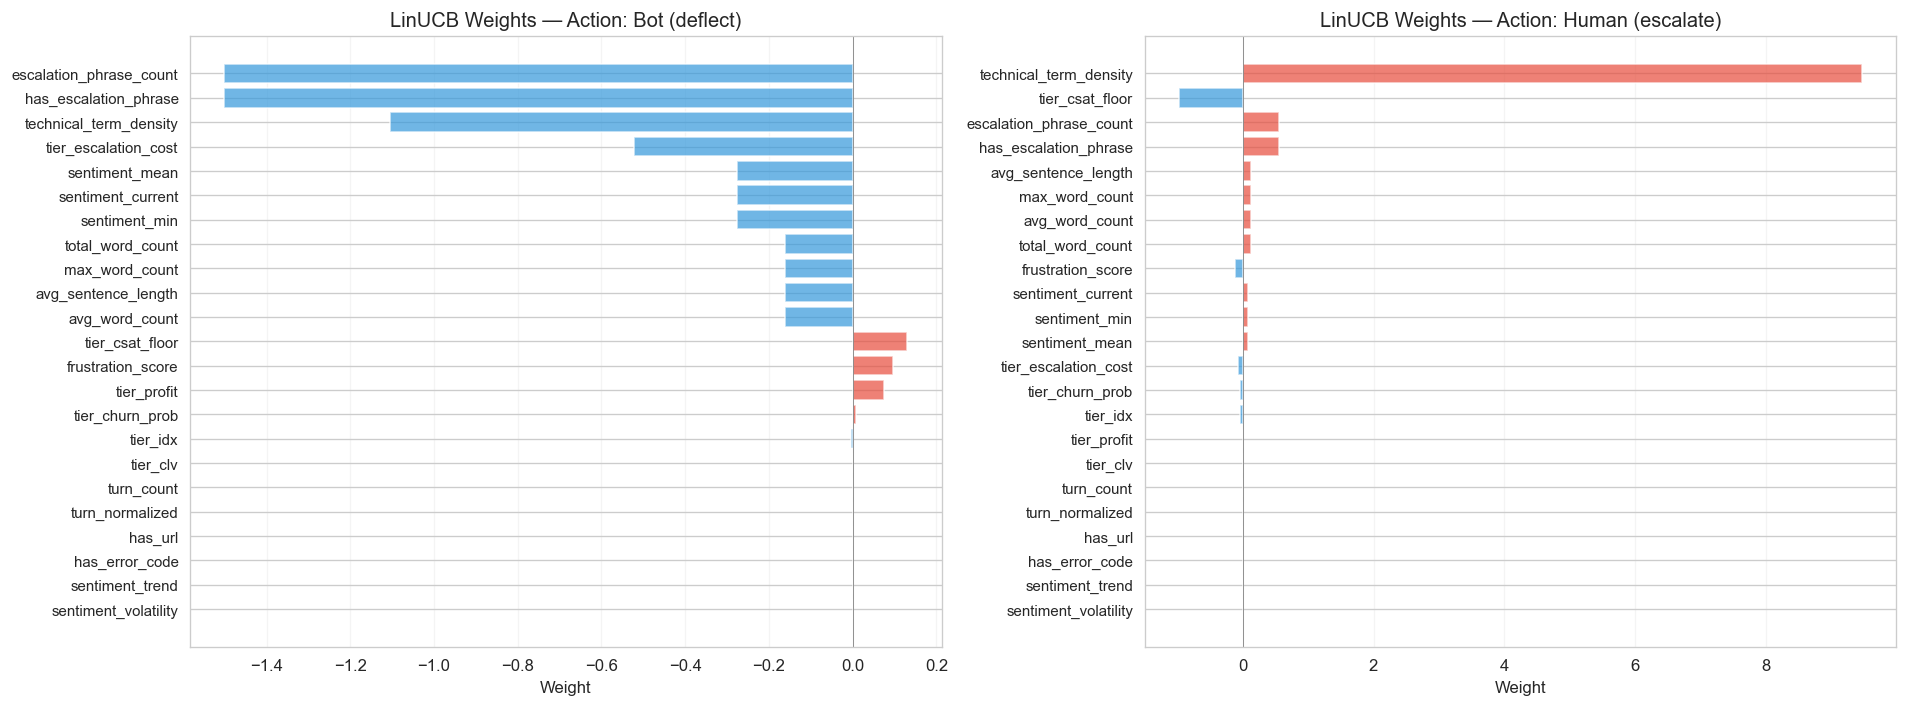

Top 5 features for ESCALATION decision:
  technical_term_density   : +9.4605
  tier_csat_floor          : -0.9747
  escalation_phrase_count  : +0.5539
  has_escalation_phrase    : +0.5539
  avg_sentence_length      : +0.1258


In [39]:
# ─── LinUCB Feature Importance ───
weights = linucb_agent.get_action_weights()
feature_names = get_feature_names()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for action, ax in zip([0, 1], axes):
    w = weights[action]
    sorted_idx = np.argsort(np.abs(w))[::-1]

    colors = ['#e74c3c' if w[i] > 0 else '#3498db' for i in sorted_idx]
    ax.barh(range(len(w)), w[sorted_idx], color=colors, alpha=0.7)
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Weight')
    action_name = 'Bot (deflect)' if action == 0 else 'Human (escalate)'
    ax.set_title(f'LinUCB Weights — Action: {action_name}')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

# Top features
print("Top 5 features for ESCALATION decision:")
w_esc = weights[1]
top_esc = np.argsort(np.abs(w_esc))[::-1][:5]
for idx in top_esc:
    print(f"  {feature_names[idx]:25s}: {w_esc[idx]:+.4f}")

## Summary

| Outcome | Result |
|---------|--------|
| **Economically optimal thresholds** | Derived per-tier (Free→never, Pro→moderate, Biz+→aggressive) |
| **Contextual bandit vs. rule-based** | LinUCB/TS outperform rules by learning conversation-level signals |
| **Cost-aligned evaluation** | Monthly profit, not accuracy, drives policy selection |
| **Sensitivity analysis** | CSA cost & churn elasticity are high-sensitivity; inference cost is low |
| **Go/No-Go** | Deployable if ROI-positive with ΔCSAT > -0.1 |
| **Capacity allocation** | Priority score ranks conversations for limited human slots |

**Key insight:** A simple tier-based rule ignores conversation-level features. The contextual bandit
learns that a frustrated Free-tier user may warrant escalation (brand damage) while a routine
Enterprise password reset does not — **the optimal policy depends on real-time conversation features,
not just tier membership.**